# **There Is No Hiding Sleep Deprevation**
## DSC 101
### CJ Sherer and Kirsten Pallasch

## **1. Abstract**

Sleep deprivation, defined as getting anything less than 7 hours of sleep, is generally known to have adverse effects on physical and neural functions. However, it is an area with many moving pieces behind the scenes that are not simply cut and dry, so establishing a better understanding, as this study aims to do, is quite important. The goal of this study is to predict the presence of sleep deprivation using common measurements of cognitive ability. Using the information provided in the files, the assessments of nine individuals before and after a 24-hour period of sleep deprivation became a dataset of 18 total observations. By comparing the results of the two tests, based on factors such as reaction time and oxygen levels, a model was constructed using a test-train split of 75% to 25% to classify observations as sleep-deprived or not. Using that model, powered by the selected variables of interest, sleep deprivation or a lack thereof was correctly identified in 80 percent of observations. Furthermore, it seemed as though measures like attention accuracy and reaction time were stronger indicators of sleep-deprived individuals compared to something like working memory. Successfully predicting sleep deprivation could be impactfully applied in many ways, primarily regarding the analysis of neurological disorders. Visible symptoms of sleep deprivation are similar to those of other medical conditions, so being able to determine whether sleep deprivation is the culprit may speed up the process for someone to get the proper treatments and solutions.

In [2]:
# import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

## **2. Introduction**

Data for this study came from PhysioNet and was collected by researchers at the University of Oklahoma. Assisted by the Cambridge Neuropsychological Test Automated Battery, they were able to measure the cognitive ability of nine healthy, young adult participants before and after sleep deprivation using tests such as rapid visual processing and motor screening. Additionally, a platform consisting of 16 photodetectors plus 16 sources emitting 760nm and 850nm wavelengths allowed the researchers to observe how efficiently oxygen and glucose were flowing throughout the brain. This dataset was originally used to identify the relationship between sleep deprivation and common body mechanisms, as well as to see its effect on the frontal cortex specifically.

Source: Mukli, Peter, et al. "Effect of 24-hour sleep deprivation on cerebral hemodynamics and cognitive performance" (version 1.0.0). PhysioNet (2021). RRID:SCR_007345. https://doi.org/10.13026/669h-cx11

Under the final dataframe created for this study, the shape of the data is 18 observations and 8 total variables, although one of which is the timestamp of either before or after sleep deprivation that serves as the target variable, and another is the respective subject IDs. The target variable thus splits the dataset into two groups of nine, where each observation has the same six pieces of information: (1) brain signals from 760 nm wavelength to detect deoxygenated blood, (2) signals from 850 nm wavelength to detect oxygenated blood, (3) calculated ratio for the balance of oxygenated and deoxygenated blood in the brain, (4) reaction time, (5) attention accuracy, and (6) working memory.

**NOTE: Since the data for this study was compiled using multiple files, the following four code chunks to display the shape and data types for this dataset can only be run AFTER the final dataframe is created.**

In [27]:
# shape of the data
final_df.shape

(18, 8)

In [28]:
# head of the data
final_df.head()

,Subject ID,Sleep Deprivation,760nm Mean,850nm Mean,Oxygen Balance Ratio,Median Reaction Time,Attention Accuracy,Working Memory
0,008,before,0.088651,0.094925,1.070764,395.0,0.9611,10.0
1,010,before,0.080165,0.113291,1.413233,351.0,0.9306,3.0
2,003,before,0.050825,0.100544,1.978221,337.5,0.9484,2.0
3,005,before,0.066028,0.112714,1.707058,346.5,0.9851,2.0
4,004,before,0.049165,0.118709,2.414520,322.0,0.9391,2.0


In [29]:
# tail of the data
final_df.tail()

,Subject ID,Sleep Deprivation,760nm Mean,850nm Mean,Oxygen Balance Ratio,Median Reaction Time,Attention Accuracy,Working Memory
13,006,after,0.085522,0.108358,1.267015,326.0,0.9804,2.0
14,001,after,0.072018,0.114286,1.586906,329.5,0.9995,2.0
15,004,after,0.048365,0.115533,2.388758,401.5,0.8819,8.0
16,010,after,0.080298,0.132119,1.645362,334.0,0.9204,2.0
17,007,after,0.094778,0.097590,1.029670,354.5,0.8772,2.0


In [30]:
# display variable data types
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Subject ID            18 non-null     object 
 1   Sleep Deprivation     18 non-null     object 
 2   760nm Mean            18 non-null     float64
 3   850nm Mean            18 non-null     float64
 4   Oxygen Balance Ratio  18 non-null     float64
 5   Median Reaction Time  18 non-null     float64
 6   Attention Accuracy    18 non-null     float64
 7   Working Memory        18 non-null     float64
dtypes: float64(6), object(2)
memory usage: 1.3+ KB


## **3. Data Preprocessing**

In [3]:
# read given CSV
cognative = pd.read_csv("SD_CANTAB_DB_public.csv")

In [4]:
# unzip zipped file from working directory

import zipfile

zip_path = "effect-of-24-hour-sleep-deprivation-on-cerebral-hemodynamics-and-cognitive-performance-1.0.0.zip"
extract_folder = "unzipped_data"

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_folder)

print("Done unzipping")

Done unzipping


In [5]:
# set correct paths
main_folder = "unzipped_data/effect-of-24-hour-sleep-deprivation-on-cerebral-hemodynamics-and-cognitive-performance-1.0.0"

before_folder = os.path.join(main_folder, "gr1_before")
after_folder = os.path.join(main_folder, "gr2_after")

print("Before folders:", os.listdir(before_folder))
print("After folders:", os.listdir(after_folder))

Before folders: ['001_before', '003_before', '004_before', '005_before', '006_before', '007_before', '008_before', '009_before', '010_before']
After folders: ['001_after', '003_after', '004_after', '005_after', '006_after', '007_after', '008_after', '009_after', '010_after']


In [ ]:
# go into files and get info from participants
rows = []

def collect_files(base_folder, timepoint):
    for participant_folder in os.listdir(base_folder):
        participant_path = os.path.join(base_folder, participant_folder)

        if os.path.isdir(participant_path):
            row = {
                "participant_folder": participant_folder,
                "timepoint": timepoint,
                "folder_path": participant_path,
                "Subject ID": participant_folder[:3],  # gets 001 from 001_before
                "inf_file": None,
                "evt_file": None,
                "set_file": None,
                "wl1_file": None,
                "wl2_file": None,
                "hdr_file": None,
                "tpl_file": None,
                "avg_file": None,
                "config_file": None,
                "mat_file": None
            }

            for file in os.listdir(participant_path):
                full_path = os.path.join(participant_path, file)
                lower_file = file.lower()

                if lower_file.endswith(".inf"):
                    row["inf_file"] = full_path
                elif lower_file.endswith(".evt"):
                    row["evt_file"] = full_path
                elif lower_file.endswith(".set"):
                    row["set_file"] = full_path
                elif lower_file.endswith(".wl1"):
                    row["wl1_file"] = full_path
                elif lower_file.endswith(".wl2"):
                    row["wl2_file"] = full_path
                elif lower_file.endswith(".hdr"):
                    row["hdr_file"] = full_path
                elif lower_file.endswith(".tpl"):
                    row["tpl_file"] = full_path
                elif lower_file.endswith(".avg"):
                    row["avg_file"] = full_path
                elif lower_file.endswith(".txt"):
                    row["config_file"] = full_path
                elif lower_file.endswith(".mat"):
                    row["mat_file"] = full_path

            rows.append(row)

collect_files(before_folder, "before")
collect_files(after_folder, "after")

files_df = pd.DataFrame(rows)
files_df

In [7]:
# function to read one file
def read_signal_file(file_path):
    with open(file_path, "r") as f:
        values = f.read().split()
    return np.array(values, dtype=float)

In [8]:
# build a simple data frame for the recorded signals
signal_df = files_df[["Subject ID", "timepoint", "wl1_file", "wl2_file"]].copy()

In [9]:
# get actual signals from those files
signal_df["wl1"] = signal_df["wl1_file"].apply(read_signal_file)
signal_df["wl2"] = signal_df["wl2_file"].apply(read_signal_file)

In [10]:
# clean up result
signal_df = signal_df.drop(columns=["wl1_file", "wl2_file"])

In [11]:
# get mean of wl files
signal_df['wl1_mean'] = signal_df['wl1'].apply(np.mean)
signal_df['wl2_mean'] = signal_df['wl2'].apply(np.mean)

In [12]:
# create the oxygen balance ratio
signal_df['wl_ratio'] = signal_df['wl2_mean'] / signal_df['wl1_mean']

In [13]:
# create new data frame with features from wl files
signal_features_df = signal_df[
    ['Subject ID',
     'timepoint',
     'wl1_mean',
     'wl2_mean',
     'wl_ratio']].copy()

In [14]:
# alter given CSV to prep for a merge with the dataframe
cognative[["id_part", "timepoint"]] = cognative["Subject ID"].str.split("_", expand=True)

In [15]:
# recode ID feature
cognative["Subject ID"] = cognative["id_part"].str.replace("SUBJ", "")

In [16]:
# drop id_part
cognative = cognative.drop(columns = ['id_part'])

In [17]:
# select only the relevant features
csv_features_df = cognative[[
    'Subject ID',
    'timepoint',
    'RTIFMDRT',
    'RVPA',
    'SWMS'
]].copy()

In [18]:
# check to see if subject ID and timepoint match in each dataframe
print(signal_features_df.head())
print(csv_features_df.head())

  Subject ID timepoint  wl1_mean  wl2_mean  wl_ratio
0        001    before  0.079350  0.121776  1.534669
1        003    before  0.050825  0.100544  1.978221
2        004    before  0.049165  0.118709  2.414520
3        005    before  0.066028  0.112714  1.707058
4        006    before  0.086079  0.109645  1.273770
  Subject ID timepoint  RTIFMDRT    RVPA  SWMS
0        001    before     320.5  0.9954   2.0
1        002    before     330.5  0.8831   7.0
2        003    before     337.5  0.9484   2.0
3        004    before     322.0     NaN   2.0
4        005    before     346.5  0.9851   2.0


In [19]:
# check that timepoint is the same for both dfs
print(signal_features_df["timepoint"].unique())
print(csv_features_df["timepoint"].unique())

['before' 'after']
['before' nan 'after']


In [20]:
# check for missing values that could affect merge
cognative[cognative["timepoint"].isna()][["Subject ID"]]

,Subject ID
10,NaN


In [21]:
# drop that timepoint
csv_features_df = csv_features_df.dropna(subset = ['timepoint'])

In [22]:
# create final dataframe
final_df = signal_features_df.merge(
    csv_features_df,
    on = ['Subject ID', 'timepoint'],
    how = 'inner'
)

In [23]:
# see if there are missing values
final_df.isnull().sum()

Subject ID    0
timepoint     0
wl1_mean      0
wl2_mean      0
wl_ratio      0
RTIFMDRT      0
RVPA          1
SWMS          0
dtype: int64

In [24]:
# fill missing value using the median
final_df["RVPA"] = final_df["RVPA"].fillna(final_df["RVPA"].median())

In [25]:
# ensure no missing values remain
final_df.isnull().sum()

Subject ID    0
timepoint     0
wl1_mean      0
wl2_mean      0
wl_ratio      0
RTIFMDRT      0
RVPA          0
SWMS          0
dtype: int64

In [26]:
# rename columns to make further analysis clearer
final_df.rename(columns={"timepoint": "Sleep Deprivation",
                         "wl1_mean": "760nm Mean",
                         "wl2_mean": "850nm Mean",
                         "wl_ratio": "Oxygen Balance Ratio",
                         "RTIFMDRT": "Median Reaction Time",
                         "RVPA": "Attention Accuracy",
                         "SWMS": "Working Memory"}, inplace=True)

In [27]:
# display final dataframe
final_df.head()

,Subject ID,Sleep Deprivation,760nm Mean,850nm Mean,Oxygen Balance Ratio,Median Reaction Time,Attention Accuracy,Working Memory
0,001,before,0.079350,0.121776,1.534669,320.5,0.9954,2.0
1,003,before,0.050825,0.100544,1.978221,337.5,0.9484,2.0
2,004,before,0.049165,0.118709,2.414520,322.0,0.9391,2.0
3,005,before,0.066028,0.112714,1.707058,346.5,0.9851,2.0
4,006,before,0.086079,0.109645,1.273770,309.0,0.9949,3.0


## **4. Visualization**

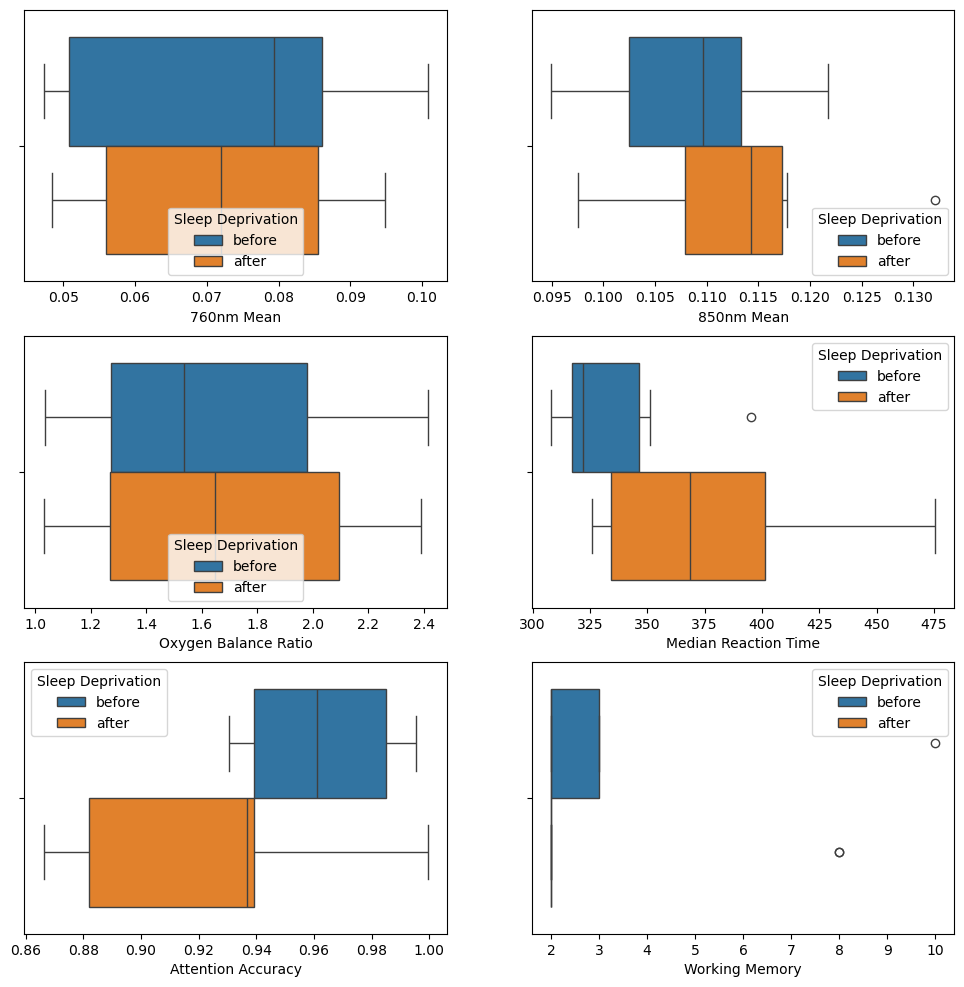

In [28]:
# create side by side boxplots for each input variable
inputs = ["760nm Mean",
          "850nm Mean",
          "Oxygen Balance Ratio",
          "Median Reaction Time",
          "Attention Accuracy",
          "Working Memory"]

plt.figure(figsize=(12,12))

for i in range(0, len(inputs)):
  plt.subplot(3,2,i+1)
  sns.boxplot(data = final_df,
           x = inputs[i],
           hue = "Sleep Deprivation"
           )

plt.show()

Above are boxplots that display the distributions of each input feature chosen for the study, color-coded by whether the observation is sleep-deprived or not. Variables like "Oxygen Balance Ratio" and the "760nm Mean" appear to have a somewhat normal distribution, with fairly even spreads and centers near where they should be, but both are far from being truly normal. Similarly, "Attention Accuracy", "Median Reaction Time", and "850nm Mean" all seem to have normal distributions across the non-sleep-deprived observations, as those boxplots show a generally uniform distribution and relevant center value. However, for the group after sleep deprivation in those variables, the spreads become visibly skewed either to the left for "850nm Mean" or to the right in the other two. Unlike the rest, "Working Memory" is not normally distributed in the slightest, as nearly every value is clustered at 2 or 3, while extreme outliers sit at 8 and 10. And although "Median Reaction Time" and "850nm Mean" also contain outliers, they must be kept in the dataframe because they are still real observations, and the sample size of this data is much too small to remove them.

As it relates to the research goal of this project, it appears that "Median Reaction Time" and "Attention Accuracy" will be the most helpful. For the former, there looks to be a noticeably faster reaction time for the patients before they were sleep deprived, and for the latter, patients without sleep deprivation seem to have higher accuracy in their attention. Likewise, the differences between groups in the brain activity measurements using "850nm Mean" as well as the "Working Memory" results suggest that these features may also aid in detecting sleep deprivation. As mentioned previously, though, all of these insights must be taken with a grain of salt due to the minute sample size of this study.

## **5. Input Preparation**



In [29]:
# estaglish X and y
X = final_df.drop(columns = ["Subject ID", "Sleep Deprivation"])
y = final_df["Sleep Deprivation"]

In [30]:
# factorize the target variable where 0 is before
y = y.factorize()[0]
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [31]:
# import function to split data
from sklearn.model_selection import train_test_split

In [32]:
# split the data into training and test groups
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                   test_size = 0.25,
                                                   random_state = 5)

In [33]:
# import function to standardize input features
from sklearn.preprocessing import StandardScaler

In [34]:
# standardize X variables
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## **6. Model Building**

In [35]:
# import model and create an instance
from sklearn.linear_model import LogisticRegression
log_reg_model = LogisticRegression()

In [36]:
# create model based on training data
log_reg_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [37]:
# determine model parameters for features and the intercept
weights = log_reg_model.coef_
intercept = log_reg_model.intercept_

In [38]:
# convert beta values into single array
weights.ravel()

array([ 0.28681389,  0.21551307, -0.02442528,  0.55675806, -0.66527485,
       -0.46420884])

In [39]:
# create a table to vizualize the relationships of the parameters
coef_df = pd.DataFrame({
    "Feature": X.columns.values,
    "Betas": weights.ravel(),
    "Odds": np.exp(weights.ravel())
})
coef_df

,Feature,Betas,Odds
0,760nm Mean,0.286814,1.332176
1,850nm Mean,0.215513,1.240498
2,Oxygen Balance Ratio,-0.024425,0.975871
3,Median Reaction Time,0.556758,1.745006
4,Attention Accuracy,-0.665275,0.514132
5,Working Memory,-0.464209,0.628632


## **7. Performance Evaluation**

In [40]:
# use the model to make predictions on the test data
y_test_pred = log_reg_model.predict(X_test_scaled)

In [41]:
# import libraries for model evaluation
from sklearn.metrics import (accuracy_score,
                            precision_score,
                            recall_score,
                            f1_score,
                            confusion_matrix,
                            classification_report)

In [42]:
# initialize evaluation methods
accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred, average = 'binary')
recall = recall_score(y_test, y_test_pred, average='binary')
f1 = f1_score(y_test, y_test_pred, average='binary')

In [43]:
# display model evaluation
print(f"Accuracy Score : {accuracy:.4f}")
print(f"Precision Score: {precision:.4f}")
print(f"Recall Score   : {recall:.4f}")
print(f"F1 Score       : {f1:.4f}")

Accuracy Score : 0.8000
Precision Score: 0.6667
Recall Score   : 1.0000
F1 Score       : 0.8000


In [44]:
# create confustion matrix
cm = confusion_matrix(y_test, y_test_pred)
cm

array([[2, 1],
       [0, 2]])

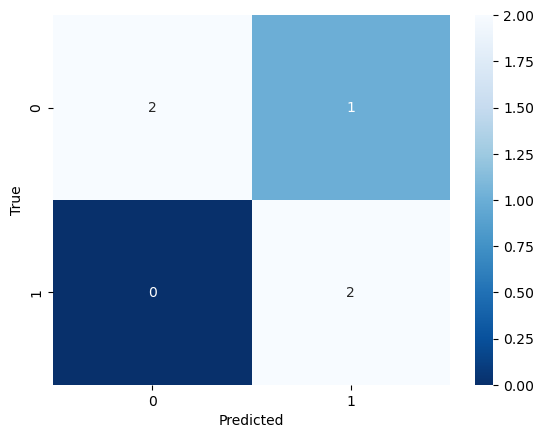

In [45]:
# visualize confusion matrix using a heatmap
sns.heatmap(cm,
           annot = True,
           cmap = "Blues_r")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.show()

Represented above is simply the heatmap version of the confusion matrix for this model, which had a train-test split of 75 and 25 percent, respectively. Since the sample size of this dataset was less than 20, the test set consisted of only 5 observations, but of those, this model correctly identified 4 of them. True negatives and true positives each occurred twice, while the one incorrect classification was a type I error false positive. Ultimately, additional observations in the training and especially the test set would make the visualization more relevant.

In [47]:
# overall model evaluation
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       1.00      0.67      0.80         3
           1       0.67      1.00      0.80         2

    accuracy                           0.80         5
   macro avg       0.83      0.83      0.80         5
weighted avg       0.87      0.80      0.80         5



## **8. Conclusion**

The machine learning model had an accuracy score of 80%, suggesting that with any given set of data, it would be able to correctly predict the lack or presence of sleep deprivation 8 out of 10 times. Using a weighted average, the model was shown to be 87% precise, identifying all cases of after sleep deprivation but missing one case before sleep deprivation. Recall scores for the model support that claim, as it was a perfect 1.00 for the "after" group but only a 0.67 for the "before" group, which it went two for three on. Similarly, the F1-score of 0.80 highlights how this study still has plenty of room for improvement. Nonetheless, through those findings, it is evident that brain patterns and function are impacted by sleep deprivation. In the medical field, such results have valuable significance as they can help better understand neurological functions and disorders. A deeper, more expanded study of how long-term sleep deprivation impacts the brain could help draw stronger conclusions in this area.

Next steps for this model include many options, but one of the more notable ones would be further exploration of the wl1 and wl2 files that recorded the brain signal. 48 channels captured brain activity via light frequency signals, but this study aggregated those values to make for a clean comparison with other variables like memory and attention. However, proper implementation of those files could help medical professionals understand which parts of the brain are most impacted by short sleep duration and make comparisons with other physical or neurological functions. Moreover, using all the available data from the original dataset publication, such as the evt files, would avoid missing any potential insights and may boost the performance of a classification model.

One of the biggest limitations of this study was the small sample size of a mere nine participants, and that must be taken into account when considering the larger population. Although the small sample does not completely discredit the model, it is quite likely that more observations would yield a more beneficial result. Furthermore, the accuracy of the study is again reduced by the fact that only young males participated, as leaving out females and other age ranges is not representative of society as a whole. While these groups should be included to improve both the study and the model, there are plenty of avenues to pursue, such as varying the severity of the sleep deprivation.  